### Tool Node 
- tool node is a prebuilt node type that acts as a bridge between you graph and external tools(functions, APIs, utilities)
- normally in langgraph you write you node function yourself: it takes a state and returns a state
- a tool node is a ready-made node that knows how to handle a list of langchhain tools 
- its job: listen from tool calls from llm like "call search()" or "get weather()" and automatically rout the request to the correct tool, then pass the tool output again to the graph


### tools_condition
-prebuild conditional edge function that helps your graph decide: "should the flow go to the ToolNode next or back to LLM?"

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition 
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool # to make custom tool

import requests
import random
import os

In [2]:
load_dotenv()
key = os.getenv("GROQ_API_KEY")

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=key)

In [4]:
#Tools
search_tool = DuckDuckGoSearchRun(region = "us-en")

@tool
def calculator(first_num: float, second_num: float, operation:str) -> dict:
    """
    Perform a basic arithmentic operaion on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation =="add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num":second_num, "operation":operation, "result":result}
    
    except Exception as ex:
        return {"error": str(ex)}
    




@tool
def get_stock_price(symbol:str)->dict:
    """
    Fetch latest stock price for a given symbol (e.g. "AAPL", "TSLA")
    using Alpha Vantage with API key in the URL
    """

    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=WAWAA1HR20EIM0XX"
    r = requests.get(url)
    return r.json()
    

In [5]:
#make tool list 
tools = [search_tool, get_stock_price, calculator]

#make the LLM tool aware

llm_with_tool = llm.bind_tools(tools)

In [6]:
#state 
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [7]:
#graph node
def chat_node(state: ChatState):
    """LLM node that may answer the request ot request a tool call."""
    messages = state["messages"]
    response = llm_with_tool.invoke(messages)
    return {"messages":[response]}

tool_node = ToolNode(tools) # executes tool calls

In [8]:
#graph structure
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [9]:
graph.add_edge(START, "chat_node")

#if llm asked for a tool go to tool node else finish
graph.add_conditional_edges("chat_node", tools_condition)

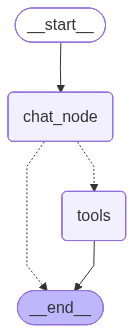

In [10]:
chatbot = graph.compile()
chatbot

In [11]:
# regular chat

out = chatbot.invoke({"messages":[HumanMessage(content="hello")]})
print(out["messages"][-1].content)

I'm here to help with any questions or tasks you may have. What's on your mind today?


In [12]:
# regular chat

out = chatbot.invoke({"messages":[HumanMessage(content="what is 2*3")]})
print(out["messages"][-1].content)

{"first_num": 2.0, "second_num": 3.0, "operation": "mul", "result": 6.0}


In [13]:
# regular chat

out = chatbot.invoke({"messages":[HumanMessage(content="what is stock price of apple")]})
print(out["messages"][-1].content)

{"Global Quote": {"01. symbol": "AAPL", "02. open": "229.2200", "03. high": "234.5100", "04. low": "229.0200", "05. price": "234.0700", "06. volume": "55824216", "07. latest trading day": "2025-09-12", "08. previous close": "230.0300", "09. change": "4.0400", "10. change percent": "1.7563%"}}


#### PROBELM : we go from chatnode to tool node and then we go to end. 
- output of tools is not refinded ( we get json as output , we need someting like "the price of apple stock is 5$")
- complex querry ( stock price of apple and how much will it cost to get 50 shares) we wanted to get stock price then we multiply it by 50 BUT our flow is a problem

#### MODIFICATION : we create a loop with out llm and tool 


In [15]:
#graph structure
graph2 = StateGraph(ChatState)

graph2.add_node("chat_node", chat_node)
graph2.add_node("tools", tool_node)

In [16]:
graph2.add_edge(START, "chat_node")

graph2.add_conditional_edges("chat_node", tools_condition)

graph2.add_edge("tools", "chat_node")

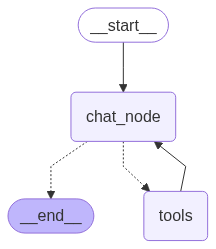

In [21]:
chatbot2 = graph2.compile()
chatbot2

In [23]:
output = chatbot2.invoke({"messages": [HumanMessage(content="what is the stock price of apple. how much whould it cost to purchase 50 shares")]})
print(output["messages"][-1].content)

The current stock price of Apple is $234.07. It would cost $11,770.50 to purchase 50 shares.


## add this feature to your chatbot